# Computer Vision
## Notebook 1 — Dataset Exploration & Preprocessing

| | |
|---|---|
| **Dataset** | **VisioDECT — Scenario-Based Multi-Drone Detection** |
| **Source** | https://www.kaggle.com/datasets/simeonajakwe/visiodect-for-scenario-based-multi-drone-detection |
| **Annotation format used** | YOLO TXT (dataset also ships Pascal-VOC XML and CSV copies) |
| **Classes (6)** | Anafi, DJI-FPV, DJI-Phantom, EFT-E410S, Mavic-Air, Mavic-Enterprise |
| **Scenarios (3)** | Cloudy · Evening · Sunny |

**This notebook covers Tasks:**
1. CONFIG
2. Environment setup
3. Dataset integrity check
4. Exploratory Data Analysis 
5. Leakage-safe Train/Val/Test split — **performed BEFORE any augmentation** 
6. Data-augmentation pipeline with per-transform justification 
7. Input-pipeline verification — before/after with boxes overlaid 
8. Written summary → informs model-size choices in Notebooks 2–5


## 1. CONFIG
All paths, class names, annotation format, image size, split ratios and seeds are declared here.
Every value in this cell is justified in the accompanying comments (viva requirement).

In [ ]:
# =============================== CONFIG ===============================

# ---- dataset ----------------------------------------------------------
DATASET_SLUG      = "simeonajakwe/visiodect-for-scenario-based-multi-drone-detection"
KAGGLE_INPUT_BASE = "/kaggle/input"        # auto-resolved below (folder names vary)
ANNOTATION_FORMAT = "YOLO TXT"             # VisioDECT ships TXT + VOC XML + CSV; we use YOLO TXT
                                           # because Notebooks 2-4 (YOLO family) consume it natively
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Global class map. Each top-level drone folder = one class.
# Per-folder YOLO txt files are remapped to these global indices when the
# final splits are materialised (folder membership is the ground truth).
CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]
CLASS_DIR_MAP = {                          # lower-cased folder name -> class id
    "anafi-extended":   0,
    "djifpv":           1,
    "djiphantom":       2,
    "eft-e410s":        3,
    "mavic_air":        4,
    "mavic_enterprise": 5,
}
SCENARIOS = ["cloudy", "evening", "sunny"] # folder case is inconsistent -> compared lower-cased

# ---- splitting (Task 5.2) --------------------------------------------
SPLIT_RATIOS = (0.70, 0.15, 0.15)  # train / val / test
# Justification: ~21k images. 15% test ≈ 3.1k images (≈520/class) gives
# statistically stable mAP estimates while keeping 70% (~14.6k) for training.
# A larger test share would shrink training data with no meaningful
# reduction in metric variance at this dataset size.
SEED = 42                                   # reproducibility of split + augmentation demos

# ---- image / pipeline -------------------------------------------------
IMG_SIZE = 640          # training resolution for Notebooks 2-5. EDA below shows drone
                        # boxes are predominantly SMALL (<32^2 px); 640 is the baseline,
                        # and the small-object finding is flagged for possible 1280 runs.
SMALL_AREA = 32**2      # COCO small-object threshold  (< 32^2  px)
LARGE_AREA = 96**2      # COCO large-object threshold  (> 96^2  px)

# ---- outputs -----------------------------------------------------------
OUTPUT_DIR   = "/kaggle/working/visiodect_yolo"   # leakage-safe YOLO dataset for NB 2-5
DATA_YAML    = f"{OUTPUT_DIR}/data.yaml"
N_SAMPLE_VIS = 6                                   # annotated samples per grid

print(f"CONFIG loaded | classes={len(CLASS_NAMES)} | split={SPLIT_RATIOS} | seed={SEED} | imgsz={IMG_SIZE}")


CONFIG loaded | classes=6 | split=(0.7, 0.15, 0.15) | seed=42 | imgsz=640


## 2. Environment Setup & Imports

In [2]:
import os, sys, json, math, random, shutil, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

try:
    import albumentations as A
except ImportError:
    !pip -q install albumentations
    import albumentations as A

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110

# every figure & table is ALSO saved to /kaggle/working/eda_outputs so results
# stay viewable after the session (and ship with the committed notebook output)
EDA_OUT = Path("/kaggle/working/eda_outputs"); EDA_OUT.mkdir(parents=True, exist_ok=True)
def save_show(name):
    plt.savefig(EDA_OUT / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("albumentations:", A.__version__)


albumentations: 2.0.8


In [3]:
# -- auto-resolve the dataset root (upload folder names / nesting vary) --
def iter_dirs(base, max_depth=4):
    """Depth-limited directory walk (avoids scanning 60k label files)."""
    stack = [(Path(base), 0)]
    while stack:
        d, dep = stack.pop()
        yield d
        if dep < max_depth:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass

def find_dataset_root(base=KAGGLE_INPUT_BASE):
    """Return the directory that directly contains the 6 drone-class folders."""
    targets = set(CLASS_DIR_MAP)
    best, best_hits = None, 0
    for d in iter_dirs(base):
        try:
            subs = {c.name.lower() for c in d.iterdir() if c.is_dir()}
        except (PermissionError, OSError):
            continue
        hits = len(subs & targets)
        if hits > best_hits:
            best, best_hits = d, hits
    if best is None or best_hits < 3:
        raise FileNotFoundError(
            "Could not locate the VisioDECT class folders under /kaggle/input. "
            "Attach the dataset via 'Add Input' and re-run.")
    return best

DATASET_ROOT = find_dataset_root()
print("Dataset root :", DATASET_ROOT)
print("Class folders:", sorted(c.name for c in DATASET_ROOT.iterdir()
                               if c.is_dir() and c.name.lower() in CLASS_DIR_MAP))


Dataset root : /kaggle/input/datasets/simeonajakwe/visiodect-for-scenario-based-multi-drone-detection/VisioDECT Dataset Upload
Class folders: ['Anafi-Extended', 'DJIFPV', 'DJIPhantom', 'EFT-E410S', 'Mavic_Air', 'Mavic_Enterprise']


## 3. Dataset Integrity Check
Before any analysis we verify: total file counts, image ↔ label pairing, corrupt/unreadable
files, and annotation-format consistency. The label folders use inconsistent casing
(`images/Cloudy` vs `labels/cloudy`) and one class (EFT-E410S) nests its TXT files inside a
`txt/` sub-folder — the indexer below is written to be robust to both.

In [4]:
def scenario_of(path: Path):
    parts = [p.lower() for p in path.parts]
    for s in SCENARIOS:
        if s in parts:
            return s
    return "unknown"

records = []
label_id_sets = defaultdict(Counter)   # raw class ids found inside txt files, per folder

for cls_dir in sorted(DATASET_ROOT.iterdir()):
    key = cls_dir.name.lower()
    if not cls_dir.is_dir() or key not in CLASS_DIR_MAP:
        continue
    cid = CLASS_DIR_MAP[key]

    # index every .txt label under this class folder by lower-cased stem
    lbl_index = defaultdict(list)
    for t in cls_dir.rglob("*.txt"):
        lbl_index[t.stem.lower()].append(t)

    # every image file that is not inside a labels/ folder
    for img in cls_dir.rglob("*"):
        if img.suffix.lower() not in IMG_EXTS:
            continue
        if "labels" in (p.lower() for p in img.parts):
            continue
        scen = scenario_of(img)
        cands = lbl_index.get(img.stem.lower(), [])
        # prefer the label whose path matches the image's scenario
        lbl = next((c for c in cands if scenario_of(c) == scen), cands[0] if cands else None)
        records.append(dict(image=str(img), label=str(lbl) if lbl else None,
                            class_id=cid, class_name=CLASS_NAMES[cid], scenario=scen))

df = pd.DataFrame(records)
print(f"Indexed images : {len(df):,}")
print(f"Missing labels : {df.label.isna().sum():,}")
display(df.groupby(["class_name", "scenario"]).size().unstack(fill_value=0)
          .assign(total=lambda x: x.sum(1)))


Indexed images : 20,924
Missing labels : 1,507


scenario,cloudy,evening,sunny,total
class_name,,,,
Anafi,1200,1200,1071,3471
DJI_FPV,1200,1200,1200,3600
DJI_Phantom,900,1200,1200,3300
EFT_E410S,1200,1200,1200,3600
Mavic_Air,1165,1165,1191,3521
Mavic_Enterprise,1188,1102,1142,3432


In [5]:
# -- corrupt-image scan + resolution capture (single pass over all images) --
sizes, corrupt = {}, []
for p in tqdm(df.image, desc="verifying images"):
    try:
        with Image.open(p) as im:
            im.verify()                       # header/CRC integrity
        with Image.open(p) as im:
            sizes[p] = im.size                # (W, H) — read from header, cheap
    except Exception as e:
        corrupt.append((p, repr(e)))

df["width"]  = df.image.map(lambda p: sizes.get(p, (np.nan, np.nan))[0])
df["height"] = df.image.map(lambda p: sizes.get(p, (np.nan, np.nan))[1])
df["ext"]    = df.image.map(lambda p: Path(p).suffix.lower())

print(f"Corrupt / unreadable images : {len(corrupt)}")
for c in corrupt[:10]:
    print("  ", c)
df = df[~df.image.isin([c[0] for c in corrupt])].reset_index(drop=True)

# -- annotation format consistency: every label line must be 'cls cx cy w h' (normalised)
bad_lines, raw_ids = 0, defaultdict(Counter)
for _, r in tqdm(df.dropna(subset=["label"]).iterrows(), total=df.label.notna().sum(),
                 desc="checking label format"):
    try:
        for ln in Path(r.label).read_text().splitlines():
            t = ln.split()
            if not t:
                continue
            if len(t) != 5 or not all(0.0 <= float(v) <= 1.0 for v in t[1:]):
                bad_lines += 1
            raw_ids[r.class_name][t[0]] += 1
    except Exception:
        bad_lines += 1

print(f"\nMalformed label lines: {bad_lines}")
print("Raw class-ids found inside each folder's TXT files "
      "(remapped to global ids 0-5 in section 5):")
for k, v in raw_ids.items():
    print(f"  {k:<18} -> {dict(v)}")
print(f"\nFile formats: {df.ext.value_counts().to_dict()}")


verifying images:   0%|          | 0/20924 [00:00<?, ?it/s]

Corrupt / unreadable images : 0


checking label format:   0%|          | 0/19417 [00:00<?, ?it/s]


Malformed label lines: 0
Raw class-ids found inside each folder's TXT files (remapped to global ids 0-5 in section 5):
  Anafi              -> {'14': 989, '13': 1200}
  DJI_FPV            -> {'8': 1200, '6': 1112, '7': 1127}
  DJI_Phantom        -> {'17': 1200, '15': 901, '16': 1200}
  EFT_E410S          -> {'11': 1200, '9': 1200, '10': 1152}
  Mavic_Air          -> {'5': 1191, '3': 1165, '4': 1163}
  Mavic_Enterprise   -> {'2': 1132, '0': 1188, '1': 1098}

File formats: {'.jpg': 20924}


### 3.5 Missing-Label Diagnosis & Recovery
The integrity check found images with **no matched YOLO TXT label**. Every VisioDECT image
contains a drone, so exporting these with empty labels would create **false-background
images** — the trainers in Notebooks 2–5 would be penalised for detecting drones that are
really there, suppressing recall for the affected class (Anafi loses its entire *cloudy*
scenario otherwise).

**Handling strategy (applied *before* EDA statistics and *before* the split):**
1. **Relaxed filename matching** — retry the TXT match case/punctuation-insensitively within
   the same class folder (accepted only when unambiguous).
2. **Pascal-VOC XML fallback** — parse `<bndbox>` from the shipped VOC copies and convert to
   normalised YOLO (class id taken from the drone folder, which is the ground truth).
3. **CSV fallback with convention verification** — VisioDECT's CSVs are **headerless** with
   the row layout `class, x, y, w, h, filename, img_width, img_height` (absolute pixels in
   the CSV's own annotation frame). Whether `(x, y)` is the box **top-left corner** or its
   **center** is undocumented, so nothing is assumed: every candidate convention (top-left,
   center, xyxy) is scored by IoU against images that have *both* a TXT label and a CSV row,
   and the winner is used only if its median agreement ≥ 0.8 over ≥ 10 overlap samples —
   otherwise the stage is skipped rather than injecting unverified coordinates. Boxes are
   normalised in the CSV's declared frame, which transfers correctly to any same-aspect
   image size.
4. **Exclusion** — anything still unlabeled after all three recovery stages is dropped from
   the dataset entirely rather than kept as background.

Section 3.6 visually confirms the CSV-recovered boxes actually sit on the drones.

In [6]:
# ---- 3.5 diagnose, recover (relaxed TXT -> VOC XML -> verified CSV), exclude
import xml.etree.ElementTree as ET
import re as _re

miss = df[df.label.isna()]
print(f"Images with no matched TXT label: {len(miss):,}")
miss_tbl = miss.groupby(["class_name", "scenario"]).size().unstack(fill_value=0)
display(miss_tbl)
miss_tbl.to_csv(EDA_OUT / "3_5_missing_labels_by_class_scenario.csv")

REC_DIR = Path("/kaggle/working/recovered_labels"); REC_DIR.mkdir(parents=True, exist_ok=True)
def norm(s):  # case/punctuation-insensitive stem
    return "".join(ch for ch in s.lower() if ch.isalnum())

# ---------- stage 1 + 2: relaxed TXT match, then VOC-XML fallback ------------
recovered_txt = recovered_xml = 0
for cls_dir in sorted(DATASET_ROOT.iterdir()):
    key = cls_dir.name.lower()
    if not cls_dir.is_dir() or key not in CLASS_DIR_MAP:
        continue
    sub = miss[miss.class_id == CLASS_DIR_MAP[key]]
    if sub.empty:
        continue
    txt_by_norm, xml_by_norm = defaultdict(list), defaultdict(list)
    for t in cls_dir.rglob("*.txt"):
        txt_by_norm[norm(t.stem)].append(t)
    for x in cls_dir.rglob("*.xml"):
        xml_by_norm[norm(x.stem)].append(x)
    for idx, r in tqdm(sub.iterrows(), total=len(sub), desc=f"txt/xml · {key}", leave=False):
        n = norm(Path(r.image).stem)
        cands = txt_by_norm.get(n, [])
        pref  = [c for c in cands if scenario_of(c) == r.scenario] or cands
        if len(pref) == 1:
            df.at[idx, "label"] = str(pref[0]); recovered_txt += 1
            continue
        xc = xml_by_norm.get(n, [])
        xp = [c for c in xc if scenario_of(c) == r.scenario] or xc
        if xp:
            try:
                root_x = ET.parse(xp[0]).getroot()
                W = float(root_x.findtext("size/width")  or r.width)
                H = float(root_x.findtext("size/height") or r.height)
                lines = []
                for ob in root_x.iter("object"):
                    bb = ob.find("bndbox")
                    x1, y1, x2, y2 = (float(bb.findtext(k))
                                      for k in ("xmin", "ymin", "xmax", "ymax"))
                    w, h = (x2 - x1) / W, (y2 - y1) / H
                    cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
                    if 0 < w <= 1 and 0 < h <= 1:
                        lines.append(f"{r.class_id} {min(max(cx,0),1):.6f} "
                                     f"{min(max(cy,0),1):.6f} {w:.6f} {h:.6f}")
                if lines:
                    op = REC_DIR / f"{r.class_name}_{r.scenario}_{Path(r.image).stem}.txt"
                    op.write_text("\n".join(lines))
                    df.at[idx, "label"] = str(op); recovered_xml += 1
            except Exception:
                pass

# ---------- stage 3: CSV fallback — schema sniffing + convention verification
# VisioDECT CSVs are HEADERLESS: class_str, n1, n2, n3, n4, filename, img_W, img_H
# where (n3, n4) are box width/height and (n1, n2) is the box position. Whether
# (n1, n2) is the TOP-LEFT corner or the CENTER is not documented, so both
# conventions (plus plain xyxy) are tested against existing TXT labels by IoU
# and the winning convention is used only if agreement is decisive.
IMG_EXT_TUPLE = (".jpg", ".jpeg", ".png", ".bmp")
def _norm_col(c):
    return _re.sub(r"[^a-z]", "", str(c).lower())

def load_csv_boxes(csv_path):
    """Returns (mapping, schema_str); mapping: {norm_stem: [(tag,a,b,c,d,W,H),...]}
    tag = "voc" (named xmin/ymin/xmax/ymax header) or "raw4" (headerless layout)."""
    try:
        peek = pd.read_csv(csv_path, header=None, nrows=3, dtype=str)
    except Exception as e:
        return None, f"unreadable ({e.__class__.__name__})"
    headerless = any(str(v).lower().endswith(IMG_EXT_TUPLE) for v in peek.iloc[0])
    mapping = defaultdict(list)
    if headerless:
        t = pd.read_csv(csv_path, header=None)
        ext_share = {c: t[c].astype(str).str.lower().str.endswith(IMG_EXT_TUPLE).mean()
                     for c in t.columns}
        fcol = max(ext_share, key=ext_share.get)
        if ext_share[fcol] < 0.5:
            return None, "headerless but no filename column found"
        num = {c: pd.to_numeric(t[c], errors="coerce") for c in t.columns if c != fcol}
        num_cols = [c for c, v in num.items() if v.notna().mean() > 0.9]
        bbox_cols = [c for c in num_cols if c < fcol][-4:]
        wh_cols   = [c for c in num_cols if c > fcol][:2]
        if len(bbox_cols) != 4:
            return None, f"headerless, but found {len(bbox_cols)} bbox cols | row0={list(peek.iloc[0])[:8]}"
        for k in range(len(t)):
            try:
                stem = norm(Path(str(t.iloc[k][fcol])).stem)
                a, b, c2, d = (float(num[c].iloc[k]) for c in bbox_cols)
                W = float(num[wh_cols[0]].iloc[k]) if len(wh_cols) == 2 else float("nan")
                H = float(num[wh_cols[1]].iloc[k]) if len(wh_cols) == 2 else float("nan")
                mapping[stem].append(("raw4", a, b, c2, d, W, H))
            except Exception:
                continue
        return mapping, (f"headerless raw4 | bbox cols {bbox_cols}, file col {fcol}, "
                         f"img-size cols {wh_cols}; rows={len(t)} (convention set by IoU below)")
    # named-header path (VOC-style)
    try:
        t = pd.read_csv(csv_path)
    except Exception as e:
        return None, f"unreadable ({e.__class__.__name__})"
    ncols = {_norm_col(c): c for c in t.columns}
    def col(*keys):
        return next((ncols[k] for k in keys if k in ncols), None)
    fcol = col("filename", "filepath", "imagename", "imagefile", "image", "file", "name", "img")
    x1c, y1c = col("xmin", "x1"), col("ymin", "y1")
    x2c, y2c = col("xmax", "x2"), col("ymax", "y2")
    Wc = col("width", "imgwidth", "imagewidth"); Hc = col("height", "imgheight", "imageheight")
    if fcol is None or not all([x1c, y1c, x2c, y2c]):
        return None, f"unrecognised schema | header={list(t.columns)[:8]}"
    for _, row in t.iterrows():
        try:
            stem = norm(Path(str(row[fcol])).stem)
            vals = [float(row[c]) for c in (x1c, y1c, x2c, y2c)]
            W = float(row[Wc]) if Wc else float("nan")
            H = float(row[Hc]) if Hc else float("nan")
            mapping[stem].append(("voc", *vals, W, H))
        except Exception:
            continue
    return mapping, f"VOC-style header ({x1c},{y1c},{x2c},{y2c}); rows={len(t)}"

def entry_to_yolo(entry, img_w, img_h, raw4_conv):
    tag, a, b, c2, d, W, H = entry
    # normalise in the CSV's own annotation frame when provided (coords were made there)
    W = W if (W and W > 0 and not math.isnan(W)) else img_w
    H = H if (H and H > 0 and not math.isnan(H)) else img_h
    if tag == "voc" or (tag == "raw4" and raw4_conv == "xyxy"):
        x1, y1, x2, y2 = a, b, c2, d
    elif raw4_conv == "topleft":
        x1, y1, x2, y2 = a, b, a + c2, b + d
    elif raw4_conv == "center":
        x1, y1, x2, y2 = a - c2/2, b - d/2, a + c2/2, b + d/2
    else:
        return None
    w, h = (x2 - x1) / W, (y2 - y1) / H
    cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
    if 0 < w <= 1 and 0 < h <= 1 and 0 <= cx <= 1 and 0 <= cy <= 1:
        return (min(max(cx, 0), 1), min(max(cy, 0), 1), w, h)
    return None

def iou_yolo(b1, b2):
    ax1, ay1, ax2, ay2 = b1[0]-b1[2]/2, b1[1]-b1[3]/2, b1[0]+b1[2]/2, b1[1]+b1[3]/2
    bx1, by1, bx2, by2 = b2[0]-b2[2]/2, b2[1]-b2[3]/2, b2[0]+b2[2]/2, b2[1]+b2[3]/2
    iw = max(0, min(ax2, bx2) - max(ax1, bx1)); ih = max(0, min(ay2, by2) - max(ay1, by1))
    inter = iw * ih
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / union if union > 0 else 0.0

print("\n--- CSV files discovered & schema report ---")
csv_maps = {}
for cls_dir in sorted(DATASET_ROOT.iterdir()):
    key = cls_dir.name.lower()
    if not cls_dir.is_dir() or key not in CLASS_DIR_MAP:
        continue
    merged = {}
    for csvf in sorted(cls_dir.rglob("*.csv")):
        m, schema = load_csv_boxes(csvf)
        print(f"  {cls_dir.name}/{csvf.relative_to(cls_dir)} -> {schema}"
              f"{'' if m is None else f' | stems mapped: {len(m):,}'}")
        if m:
            for k, v in m.items():
                merged.setdefault(k, v)
    csv_maps[key] = merged

# ---- verify: test every candidate convention against existing TXT labels ----
CONVS = ["topleft", "center", "xyxy"]
val = {c: [] for c in CONVS}; val["voc"] = []
for key, merged in csv_maps.items():
    if not merged:
        continue
    labeled = df[(df.class_id == CLASS_DIR_MAP[key]) & df.label.notna()]
    labeled = labeled.sample(min(300, len(labeled)), random_state=SEED)
    for _, r in labeled.iterrows():
        stem = norm(Path(r.image).stem)
        entries = merged.get(stem)
        if not entries:
            continue
        try:
            t = Path(r.label).read_text().split()
            txt_box = tuple(map(float, t[1:5]))
        except Exception:
            continue
        e = entries[0]
        if e[0] == "voc":
            cb = entry_to_yolo(e, r.width, r.height, None)
            if cb: val["voc"].append(iou_yolo(txt_box, cb))
        else:
            for conv in CONVS:
                cb = entry_to_yolo(e, r.width, r.height, conv)
                if cb: val[conv].append(iou_yolo(txt_box, cb))

conv_report = pd.DataFrame([(k, len(v), float(np.median(v)) if v else np.nan)
                            for k, v in val.items()],
                           columns=["convention", "overlap_n", "median_iou"]).round(3)
display(conv_report); conv_report.to_csv(EDA_OUT / "3_5_csv_convention_iou.csv", index=False)

raw4_scores = {c: np.median(val[c]) for c in CONVS if len(val[c]) >= 10}
RAW4_CONV = max(raw4_scores, key=raw4_scores.get) if raw4_scores else None
RAW4_TRUSTED = RAW4_CONV is not None and raw4_scores[RAW4_CONV] >= 0.8
VOC_TRUSTED  = len(val["voc"]) >= 10 and np.median(val["voc"]) >= 0.8
print(f"\nraw4 convention chosen: {RAW4_CONV} "
      f"(median IoU {raw4_scores.get(RAW4_CONV, float('nan')):.3f}) | trusted: {RAW4_TRUSTED}")
print(f"voc-header csvs trusted: {VOC_TRUSTED}")

recovered_csv = 0
csv_recovered_images = []
if RAW4_TRUSTED or VOC_TRUSTED:
    miss2 = df[df.label.isna()]
    id_to_key = {v: k for k, v in CLASS_DIR_MAP.items()}
    for idx, r in tqdm(miss2.iterrows(), total=len(miss2), desc="csv recovery", leave=False):
        entries = csv_maps.get(id_to_key[r.class_id], {}).get(norm(Path(r.image).stem))
        if not entries:
            continue
        lines = []
        for e in entries:
            if (e[0] == "voc" and not VOC_TRUSTED) or (e[0] == "raw4" and not RAW4_TRUSTED):
                continue
            yb = entry_to_yolo(e, r.width, r.height, RAW4_CONV)
            if yb:
                lines.append(f"{r.class_id} {yb[0]:.6f} {yb[1]:.6f} {yb[2]:.6f} {yb[3]:.6f}")
        if lines:
            op = REC_DIR / f"{r.class_name}_{r.scenario}_{Path(r.image).stem}.txt"
            op.write_text("\n".join(lines))
            df.at[idx, "label"] = str(op)
            recovered_csv += 1
            csv_recovered_images.append(r.image)
else:
    print("!! CSV stage SKIPPED — no convention reached median IoU >= 0.8 against TXT "
          "labels. No unverified boxes were injected.")

# ---------- stage 4: exclude the remainder -----------------------------------
still = df.label.isna()
excluded_unlabeled = int(still.sum())
# evidence for the viva: do any still-unlabeled images have a CSV row at all?
_id2key = {v: k for k, v in CLASS_DIR_MAP.items()}
_in_csv = sum(1 for _, r in df[still].iterrows()
              if norm(Path(r.image).stem) in csv_maps.get(_id2key[r.class_id], {}))
print(f"\nExcluded images that have ANY CSV row: {_in_csv} of {excluded_unlabeled} "
      "(0 means these frames are unannotated in TXT, VOC-XML *and* CSV — "
      "no shipped annotation source remains, so exclusion is final).")
print(f"\nRecovered via relaxed TXT match : {recovered_txt:,}")
print(f"Recovered via VOC-XML fallback  : {recovered_xml:,}")
print(f"Recovered via verified CSV      : {recovered_csv:,}")
print(f"Still unlabeled -> EXCLUDED     : {excluded_unlabeled:,}")
if excluded_unlabeled:
    excl_tbl = df[still].groupby(["class_name", "scenario"]).size().unstack(fill_value=0)
    display(excl_tbl)
    excl_tbl.to_csv(EDA_OUT / "3_5_excluded_unlabeled_by_class_scenario.csv")
df = df[~still].reset_index(drop=True)
print(f"Images continuing to EDA & split: {len(df):,}")


Images with no matched TXT label: 1,507


scenario,cloudy,evening,sunny
class_name,,,
Anafi,1200,0,82
DJI_FPV,88,73,0
EFT_E410S,0,48,0
Mavic_Air,0,2,0
Mavic_Enterprise,0,4,10


txt/xml · anafi-extended:   0%|          | 0/1282 [00:00<?, ?it/s]

txt/xml · djifpv:   0%|          | 0/161 [00:00<?, ?it/s]

txt/xml · eft-e410s:   0%|          | 0/48 [00:00<?, ?it/s]

...


raw4 convention chosen: topleft (median IoU 0.981) | trusted: True
voc-header csvs trusted: False


csv recovery:   0%|          | 0/1507 [00:00<?, ?it/s]


Excluded images that have ANY CSV row: 0 of 307 (0 means these frames are unannotated in TXT, VOC-XML *and* CSV — no shipped annotation source remains, so exclusion is final).

Recovered via relaxed TXT match : 0
Recovered via VOC-XML fallback  : 0
Recovered via verified CSV      : 1,200
Still unlabeled -> EXCLUDED     : 307


scenario,cloudy,evening,sunny
class_name,,,
Anafi,0,0,82
DJI_FPV,88,73,0
EFT_E410S,0,48,0
Mavic_Air,0,2,0
Mavic_Enterprise,0,4,10


Images continuing to EDA & split: 20,617


### 3.6 Visual Check — CSV-Recovered Boxes
The IoU verification above proves the CSV *coordinate convention* is correct on images where
TXT labels also exist. This cell closes the loop on the recovered images themselves: it
overlays the CSV-derived boxes on a sample of the recovered frames (prioritising
Anafi-cloudy, the largest recovered block) so the boxes can be visually confirmed to sit on
the drones before these labels enter the split.

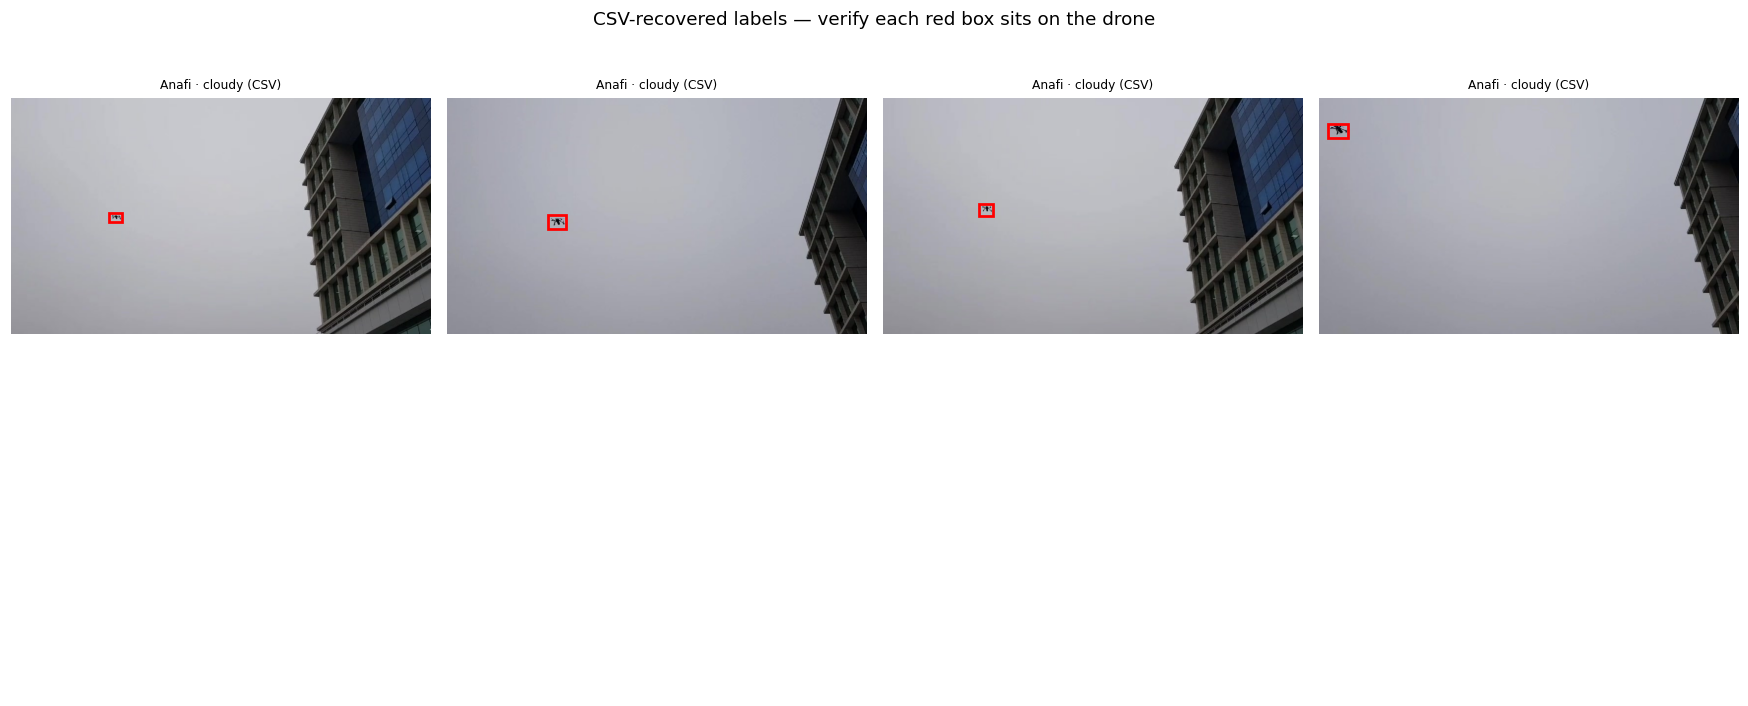

Showing 4 of 1,200 CSV-recovered images.


In [7]:
# ---- 3.6 draw CSV-recovered labels on their images --------------------------
if csv_recovered_images:
    rec = df[df.image.isin(csv_recovered_images)]
    rec = pd.concat([rec[rec.class_name == "Anafi"].head(4),
                     rec[rec.class_name != "Anafi"].head(4)]).head(8)
    fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
    for ax, (_, r) in zip(axes.ravel(), rec.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
        ax.imshow(im); ax.set_axis_off()
        ax.set_title(f"{r.class_name} · {r.scenario} (CSV)", fontsize=8)
        for ln in Path(r.label).read_text().splitlines():
            t = ln.split()
            if len(t) == 5:
                _, cx, cy, w, h = map(float, t)
                ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                                fill=False, edgecolor="red", lw=1.8))
    for ax in axes.ravel()[len(rec):]:
        ax.set_axis_off()
    fig.suptitle("CSV-recovered labels — verify each red box sits on the drone")
    plt.tight_layout(); save_show("3_6_csv_recovered_samples")
    print(f"Showing {len(rec)} of {len(csv_recovered_images):,} CSV-recovered images.")
else:
    print("No CSV-recovered images to display (CSV stage recovered nothing or was skipped).")


## 4. Exploratory Data Analysis 
We analyse: **(a)** class & scenario distribution, **(b)** image resolution / aspect-ratio /
format, **(c)** bounding-box statistics (count per image, width/height/area, COCO
small–medium–large proportions), **(d)** annotated sample images.

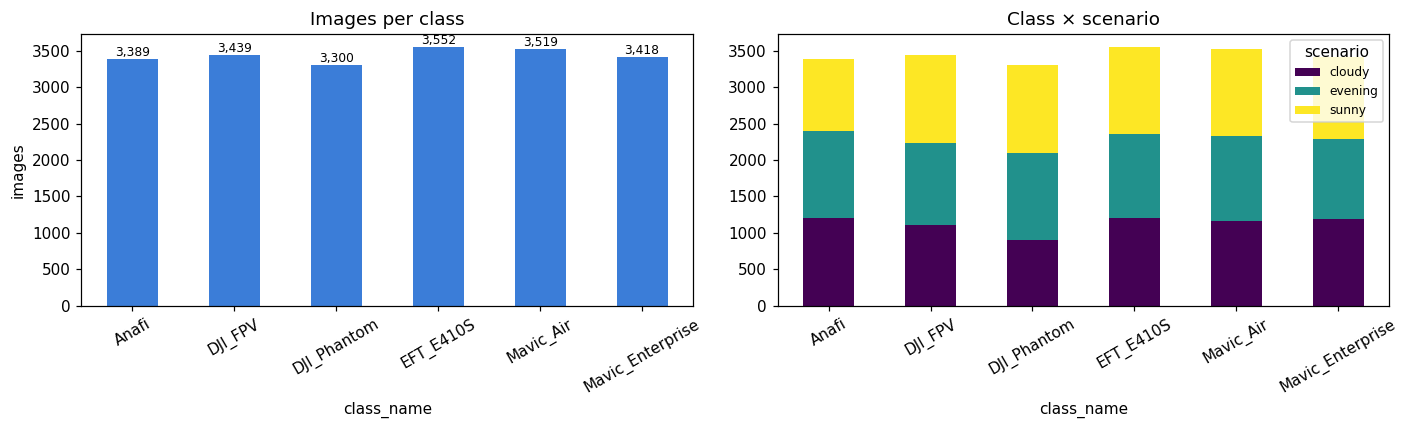

Imbalance ratio (max/min class): 1.08x -> roughly balanced


In [8]:
# ---- 4.1 class & scenario distribution ----------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

cls_counts = df.class_name.value_counts().sort_index()
cls_counts.plot.bar(ax=ax[0], color="#3b7dd8", rot=30)
ax[0].set_title("Images per class"); ax[0].set_ylabel("images")
for i, v in enumerate(cls_counts):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

pv = df.groupby(["class_name", "scenario"]).size().unstack(fill_value=0)
pv.plot.bar(stacked=True, ax=ax[1], rot=30, colormap="viridis")
ax[1].set_title("Class × scenario"); ax[1].legend(title="scenario", fontsize=8)
plt.tight_layout(); save_show('4_1_class_scenario_distribution')
pv.to_csv(EDA_OUT / '4_1_class_scenario_counts.csv')

imb = cls_counts.max() / cls_counts.min()
print(f"Imbalance ratio (max/min class): {imb:.2f}x "
      f"-> {'roughly balanced' if imb < 1.5 else 'IMBALANCED — stratification is mandatory'}")


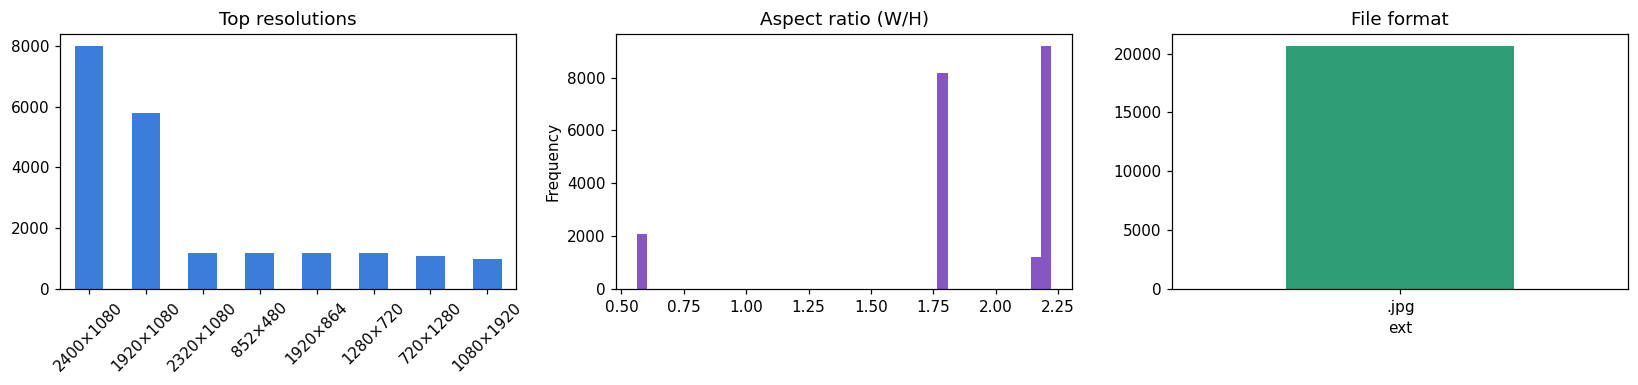

2400×1080    7984
1920×1080    5775
2320×1080    1200
852×480      1200
1920×864     1200


In [9]:
# ---- 4.2 image resolution / aspect ratio ---------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
res = (df.width.astype(str) + "×" + df.height.astype(str)).value_counts().head(10)
res.plot.bar(ax=ax[0], color="#3b7dd8", rot=45); ax[0].set_title("Top resolutions")
df["aspect"] = df.width / df.height
df.aspect.plot.hist(bins=40, ax=ax[1], color="#8657c2"); ax[1].set_title("Aspect ratio (W/H)")
df.ext.value_counts().plot.bar(ax=ax[2], color="#2f9e77", rot=0); ax[2].set_title("File format")
plt.tight_layout(); save_show('4_2_resolution_aspect_format')
print(res.head(5).to_string())


parsing boxes:   0%|          | 0/20617 [00:00<?, ?it/s]

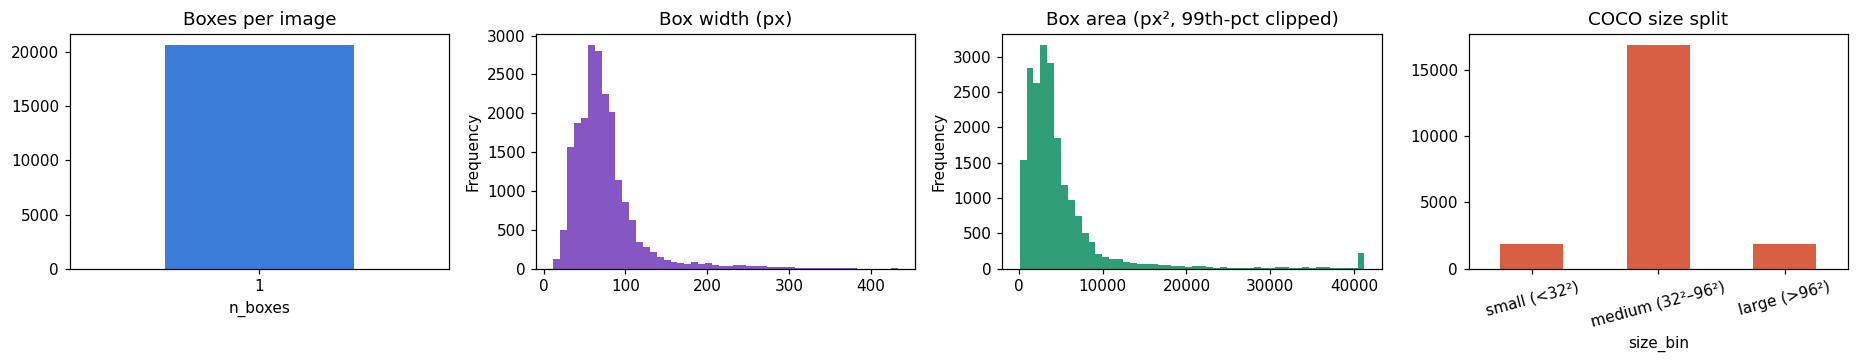

Total boxes: 20,617 | median area: 3,453 px² (≈59 px side)
Object-size profile: small (<32²): 9.0%, medium (32²–96²): 81.8%, large (>96²): 9.2%
Boxes per image: exactly one in 100.0% of labeled images
=> KEY FINDING: the dominant size bin is 'medium (32²–96²)'. This size profile + the one-drone-per-image structure drive the input-resolution and model-size choices justified in Section 8.


In [10]:
# ---- 4.3 bounding-box statistics ------------------------------------------
box_rows = []
for _, r in tqdm(df.dropna(subset=["label"]).iterrows(),
                 total=df.label.notna().sum(), desc="parsing boxes"):
    W, H = r.width, r.height
    try:
        for ln in Path(r.label).read_text().splitlines():
            t = ln.split()
            if len(t) != 5:
                continue
            _, cx, cy, w, h = map(float, t)
            bw, bh = w * W, h * H
            box_rows.append(dict(image=r.image, class_name=r.class_name,
                                 scenario=r.scenario, cx=cx, cy=cy,
                                 bw=bw, bh=bh, area=bw * bh))
            n += 1
    except Exception:
        pass

boxes = pd.DataFrame(box_rows)
per_img = boxes.groupby("image").size()
df["n_boxes"] = df.image.map(per_img).fillna(0).astype(int)

boxes["size_bin"] = pd.cut(boxes.area, [0, 32**2, 96**2, np.inf],
                           labels=["small (<32²)", "medium (32²–96²)", "large (>96²)"])

fig, ax = plt.subplots(1, 4, figsize=(17, 3.4))
df.n_boxes.value_counts().sort_index().plot.bar(ax=ax[0], color="#3b7dd8", rot=0)
ax[0].set_title("Boxes per image")
boxes.bw.plot.hist(bins=50, ax=ax[1], color="#8657c2"); ax[1].set_title("Box width (px)")
boxes.area.clip(upper=boxes.area.quantile(.99)).plot.hist(bins=50, ax=ax[2], color="#2f9e77")
ax[2].set_title("Box area (px², 99th-pct clipped)")
boxes.size_bin.value_counts().reindex(["small (<32²)", "medium (32²–96²)", "large (>96²)"]) \
     .plot.bar(ax=ax[3], color="#d95f43", rot=15); ax[3].set_title("COCO size split")
plt.tight_layout(); save_show('4_3_bbox_statistics')

sm = (boxes.size_bin == "small (<32²)").mean()
shares = boxes.size_bin.value_counts(normalize=True) \
              .reindex(["small (<32²)", "medium (32²–96²)", "large (>96²)"])
print(f"Total boxes: {len(boxes):,} | median area: {boxes.area.median():,.0f} px² "
      f"(≈{boxes.area.median()**0.5:.0f} px side)")
print("Object-size profile: " + ", ".join(f"{k}: {v:.1%}" for k, v in shares.items()))
print(f"Boxes per image: exactly one in {(df.n_boxes == 1).mean():.1%} of labeled images")
print(f"=> KEY FINDING: the dominant size bin is '{shares.idxmax()}'. "
      "This size profile + the one-drone-per-image structure drive the input-resolution "
      "and model-size choices justified in Section 8.")


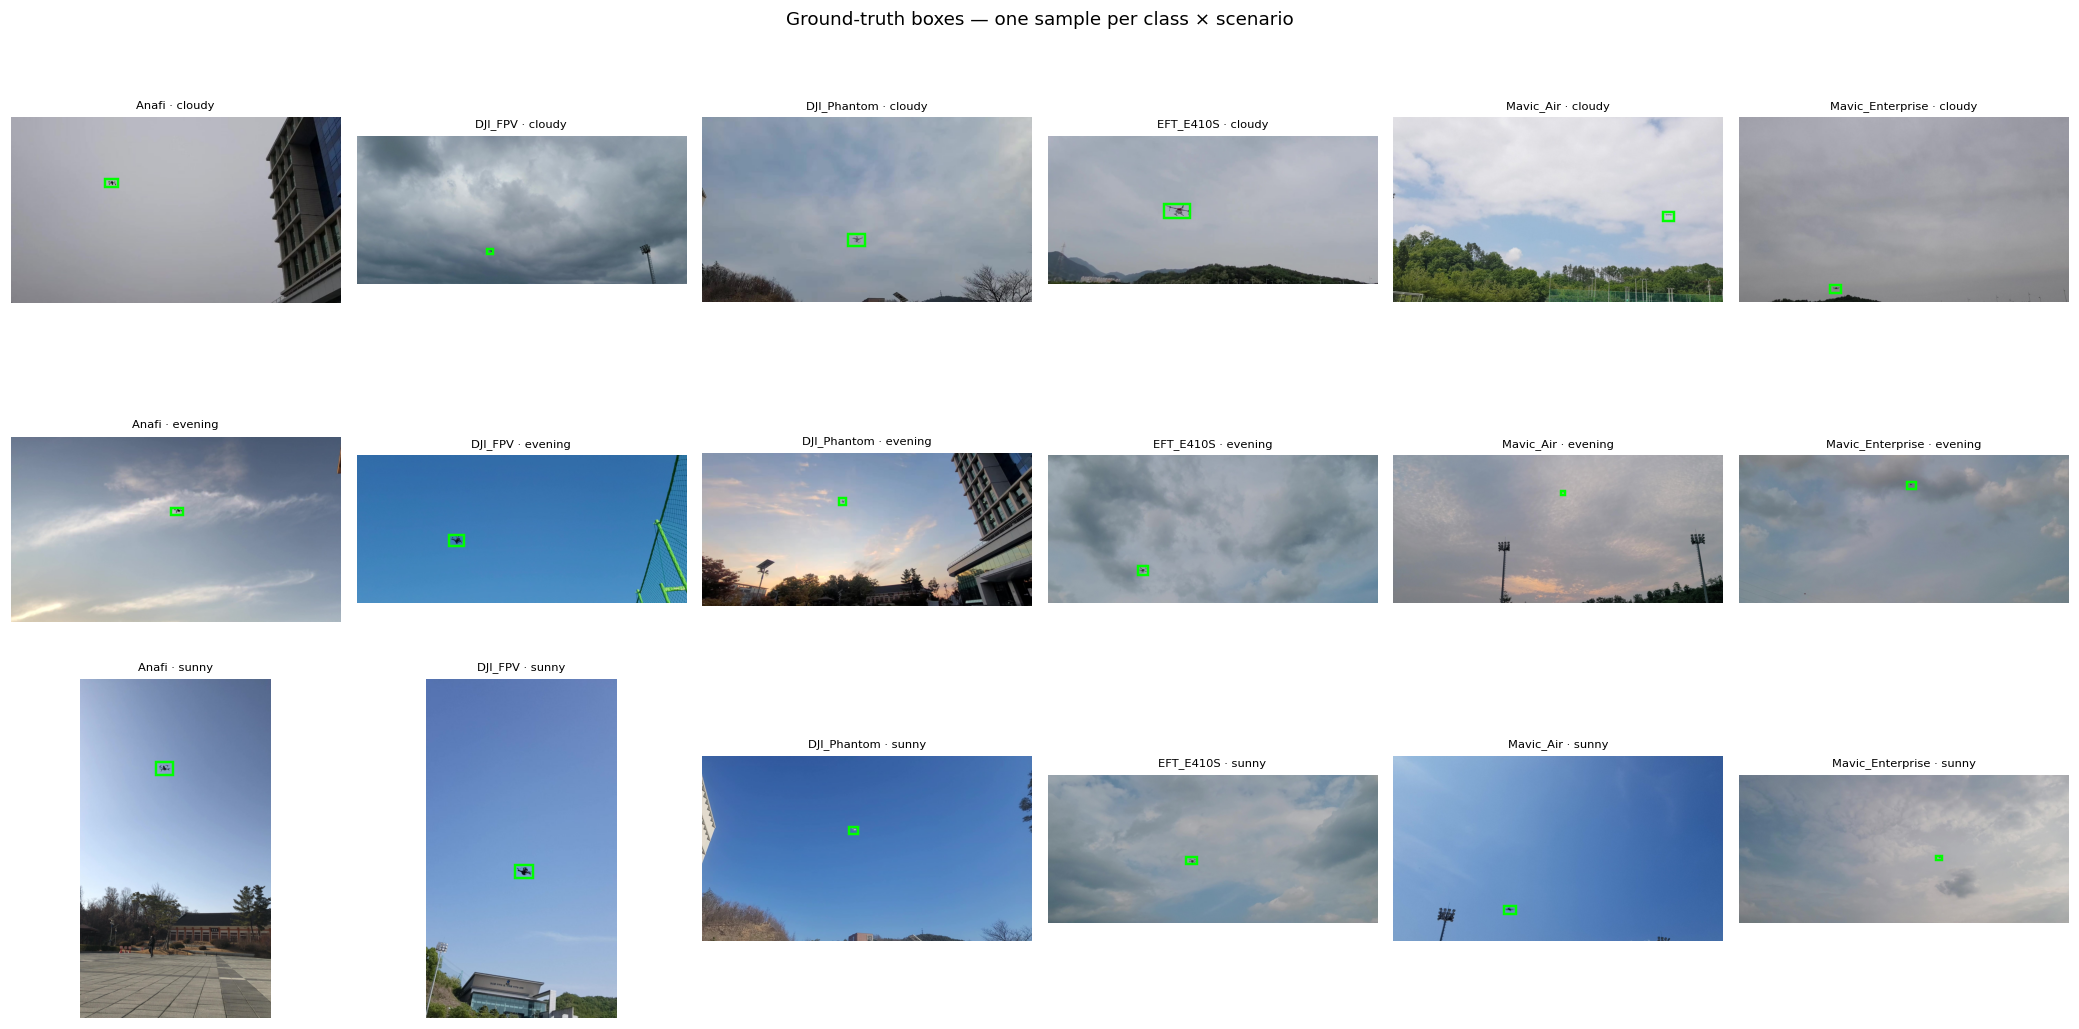

In [11]:
# ---- 4.4 annotated samples — one image per class for EACH scenario ---------
fig, axes = plt.subplots(len(SCENARIOS), len(CLASS_NAMES), figsize=(19, 9.5))
for si, scen in enumerate(SCENARIOS):
    for ci, cname in enumerate(CLASS_NAMES):
        ax = axes[si, ci]; ax.set_axis_off()
        sub = df[(df.class_name == cname) & (df.scenario == scen) & df.label.notna()]
        if sub.empty:
            ax.set_title(f"{cname}\n{scen} — no images", fontsize=7); continue
        r = sub.sample(1, random_state=SEED).iloc[0]
        im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
        ax.imshow(im); ax.set_title(f"{cname} · {scen}", fontsize=7.5)
        for ln in Path(r.label).read_text().splitlines():
            t = ln.split()
            if len(t) == 5:
                _, cx, cy, w, h = map(float, t)
                ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                                fill=False, edgecolor="lime", lw=1.6))
fig.suptitle("Ground-truth boxes — one sample per class × scenario")
plt.tight_layout(); save_show("4_4_annotated_samples_class_x_scenario")


### 4.5 Scenario Photometrics & Spatial Box Distribution
Three additional analyses that directly feed the augmentation and error-analysis design:
**(a)** mean image brightness per scenario — quantifies the sunny/cloudy/evening lighting gap
that the photometric augmentations must bridge; **(b)** spatial density of drone-box centres —
reveals whether drones cluster in one image region (informs translate augmentation and
mosaic behaviour); **(c)** box size per class and per scenario — shows whether any class or
lighting condition presents systematically smaller (harder) targets.

brightness · cloudy:   0%|          | 0/400 [00:00<?, ?it/s]

brightness · evening:   0%|          | 0/400 [00:00<?, ?it/s]

brightness · sunny:   0%|          | 0/400 [00:00<?, ?it/s]

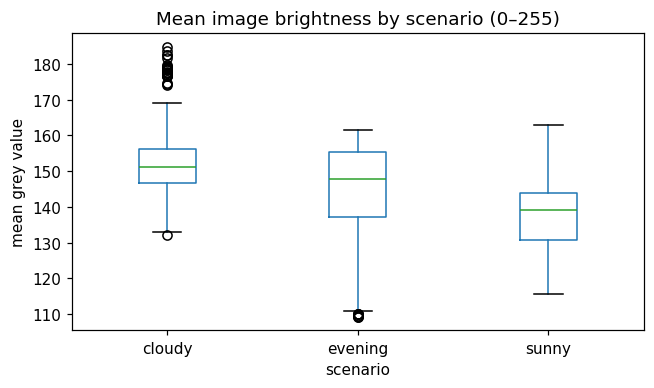

,mean,std
scenario,,
cloudy,153.4,9.8
evening,143.3,14.5
sunny,136.8,12.4


=> Brightness gap between extreme scenarios: 17 grey levels — this is the range the RandomBrightnessContrast augmentation must cover.


In [12]:
# ---- 4.5a mean brightness per scenario (sampled) ---------------------------
SAMPLE_PER_SCEN = 400
rows = []
for s in SCENARIOS:
    subset = df[df.scenario == s]
    subset = subset.sample(min(SAMPLE_PER_SCEN, len(subset)), random_state=SEED)
    for pth in tqdm(subset.image, desc=f"brightness · {s}", leave=False):
        with Image.open(pth) as im:
            rows.append((s, float(np.asarray(im.convert("L").resize((64, 64)),
                                             dtype=np.float32).mean())))
bri = pd.DataFrame(rows, columns=["scenario", "mean_brightness"])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
bri.boxplot(column="mean_brightness", by="scenario", ax=ax, grid=False)
plt.suptitle(""); ax.set_title("Mean image brightness by scenario (0–255)")
ax.set_ylabel("mean grey value"); save_show("4_5a_brightness_by_scenario")

bri_stats = bri.groupby("scenario").mean_brightness.agg(["mean", "std"]).round(1)
display(bri_stats); bri_stats.to_csv(EDA_OUT / "4_5a_brightness_stats.csv")
gap = bri_stats["mean"].max() - bri_stats["mean"].min()
print(f"=> Brightness gap between extreme scenarios: {gap:.0f} grey levels — "
      "this is the range the RandomBrightnessContrast augmentation must cover.")


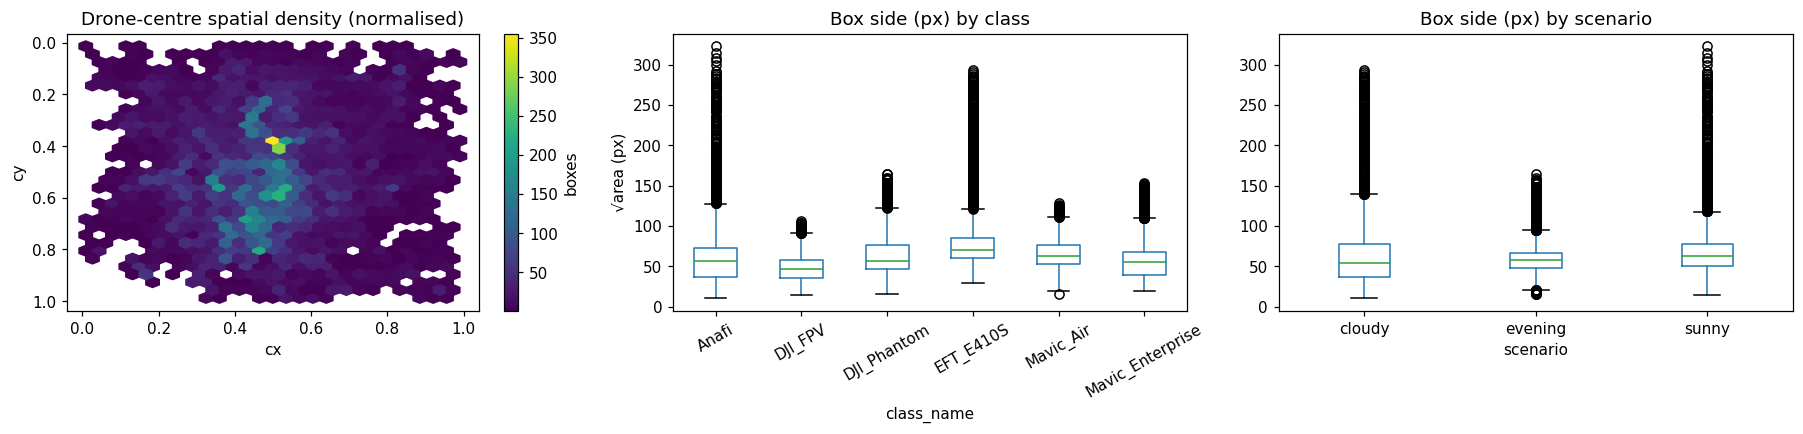

,median_side_px,p10_side_px
class_name,,
Anafi,57.1,26.9
DJI_FPV,47.2,29.2
DJI_Phantom,56.6,37.4
EFT_E410S,70.6,53.5
Mavic_Air,63.1,36.8
Mavic_Enterprise,55.1,33.3


=> Per-class size medians identify which drones present the smallest (hardest) targets — the first place to look in the error analysis of Notebooks 2–5.


In [13]:
# ---- 4.5b spatial density of box centres + box size by class / scenario ----
boxes["side"] = np.sqrt(boxes.area)

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.2))
hb = ax[0].hexbin(boxes.cx, boxes.cy, gridsize=28, cmap="viridis", mincnt=1)
ax[0].invert_yaxis(); ax[0].set_title("Drone-centre spatial density (normalised)")
ax[0].set_xlabel("cx"); ax[0].set_ylabel("cy"); fig.colorbar(hb, ax=ax[0], label="boxes")

boxes.boxplot(column="side", by="class_name", ax=ax[1], rot=30, grid=False)
ax[1].set_title("Box side (px) by class"); ax[1].set_ylabel("√area (px)")
boxes.boxplot(column="side", by="scenario", ax=ax[2], grid=False)
ax[2].set_title("Box side (px) by scenario")
plt.suptitle(""); plt.tight_layout(); save_show("4_5b_spatial_and_size_breakdown")

size_by = pd.concat([boxes.groupby("class_name").side.median().rename("median_side_px"),
                     boxes.groupby("class_name").side.quantile(.1).rename("p10_side_px")], axis=1).round(1)
display(size_by); size_by.to_csv(EDA_OUT / "4_5b_box_side_by_class.csv")
print("=> Per-class size medians identify which drones present the smallest (hardest) "
      "targets — the first place to look in the error analysis of Notebooks 2–5.")


## 5. Leakage-Safe Train / Validation / Test Split 
> **Order matters:** the split is created **now, before any augmentation is defined or
> applied**, so augmented views of one image can never appear in two different splits.

**Leakage-prevention protocol**
1. **MD5 hash of every image file** — byte-identical duplicates (e.g. the same frame stored
   under two scenario folders) are detected; only the first copy is kept, so no duplicate can
   straddle two splits.
2. **Stratified split on `class × scenario`** (18 strata) with a fixed seed — preserves both
   the class balance and the imaging-condition balance in every split.
3. **Post-split assertion** — the intersection of MD5 sets across train/val/test must be empty.

**Split-ratio justification (70/15/15).** With ≈21 k images, 15 % ≈ 3.1 k test images
(≈520 per class, ≈170 per class-scenario cell) — large enough for low-variance mAP
estimates. Allocating more to test would remove thousands of training images while barely
reducing metric variance; allocating less would make per-class error analysis unreliable.

In [14]:
# ---- 5.1 MD5 hashing + duplicate removal ----------------------------------
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

tqdm.pandas(desc="hashing images (MD5)")
df["md5"] = df.image.progress_apply(md5)

dups = df.md5.duplicated(keep="first")
print(f"Byte-identical duplicate images found & dropped: {dups.sum():,}")
df = df[~dups].reset_index(drop=True)
print(f"Images entering the split: {len(df):,}")


hashing images (MD5):   0%|          | 0/20617 [00:00<?, ?it/s]

Byte-identical duplicate images found & dropped: 14
Images entering the split: 20,603


In [15]:
# ---- 5.2 stratified 70/15/15 split ----------------------------------------
df["strata"] = df.class_name + "_" + df.scenario
tr_frac, va_frac, te_frac = SPLIT_RATIOS

train_df, hold = train_test_split(df, test_size=va_frac + te_frac,
                                  stratify=df.strata, random_state=SEED)
val_df, test_df = train_test_split(hold, test_size=te_frac / (va_frac + te_frac),
                                   stratify=hold.strata, random_state=SEED)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df.loc[part.index, "split"] = name

# ---- stratification report (per-split class counts — grading requirement) --
rep = df.groupby(["split", "class_name"]).size().unstack(fill_value=0) \
        .reindex(["train", "val", "test"])
rep["total"] = rep.sum(1)
rep["share"] = (rep.total / rep.total.sum()).round(3)
display(rep); rep.to_csv(EDA_OUT / '5_2_split_stratification_report.csv')
display(df.groupby(["split", "scenario"]).size().unstack(fill_value=0))

# ---- 5.3 leakage assertion ---------------------------------------------------
h = {s: set(df.loc[df.split == s, "md5"]) for s in ["train", "val", "test"]}
assert not (h["train"] & h["val"]) and not (h["train"] & h["test"]) \
       and not (h["val"] & h["test"]), "LEAKAGE DETECTED!"
print("\n✔ MD5 leakage check PASSED — zero shared hashes between any two splits.")


class_name,Anafi,DJI_FPV,DJI_Phantom,EFT_E410S,Mavic_Air,Mavic_Enterprise,total,share
split,,,,,,,,
train,2362,2407,2310,2486,2464,2393,14422,0.70
val,507,516,495,533,526,513,3090,0.15
test,506,516,495,533,529,512,3091,0.15


scenario,cloudy,evening,sunny
split,,,
test,1013,1041,1037
train,4726,4858,4838
val,1012,1041,1037



✔ MD5 leakage check PASSED — zero shared hashes between any two splits.


In [16]:
# ---- 5.4 materialise the YOLO dataset for Notebooks 2-5 --------------------
# Copies images and REWRITES each label's class id to the global 0-5 index
# (the drone folder is the ground-truth class; raw per-folder txt ids may all be 0).
out = Path(OUTPUT_DIR)
if out.exists():
    shutil.rmtree(out)
empty_labels = 0
for s in ["train", "val", "test"]:
    (out / s / "images").mkdir(parents=True); (out / s / "labels").mkdir(parents=True)

for _, r in tqdm(df.iterrows(), total=len(df), desc="materialising splits"):
    stem = f"{r.class_name}_{r.scenario}_{Path(r.image).stem}"       # unique, traceable name
    shutil.copy2(r.image, out / r.split / "images" / (stem + Path(r.image).suffix.lower()))
    lines = []
    if isinstance(r.label, str):
        for ln in Path(r.label).read_text().splitlines():
            t = ln.split()
            if len(t) == 5:
                lines.append(" ".join([str(r.class_id)] + t[1:]))    # remap class id
    if not lines:
        empty_labels += 1
    (out / r.split / "labels" / (stem + ".txt")).write_text("\n".join(lines))

yaml_text = (f"path: {OUTPUT_DIR}\ntrain: train/images\nval: val/images\n"
             f"test: test/images\nnc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
Path(DATA_YAML).write_text(yaml_text)

print(f"Background/empty-label images: {empty_labels}")
for s in ["train", "val", "test"]:
    print(f"  {s:<5}: {len(list((out/s/'images').iterdir())):,} images, "
          f"{len(list((out/s/'labels').iterdir())):,} labels")
print("\ndata.yaml\n" + "-"*40 + "\n" + yaml_text)
print("NOTE: after committing this notebook, add its OUTPUT as the input dataset of Notebooks 2-5.")


materialising splits:   0%|          | 0/20603 [00:00<?, ?it/s]

Background/empty-label images: 0
  train: 14,422 images, 14,422 labels
  val  : 3,090 images, 3,090 labels
  test : 3,091 images, 3,091 labels

data.yaml
----------------------------------------
path: /kaggle/working/visiodect_yolo
train: train/images
val: val/images
test: test/images
nc: 6
names: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

NOTE: after committing this notebook, add its OUTPUT as the input dataset of Notebooks 2-5.


## 6. Data-Augmentation Pipeline 
Applied to the **train split only**, *after* the split above. Each transform is tied to a
specific EDA finding:

| # | Transform | Justification (EDA-grounded) |
|---|-----------|------------------------------|
| 1 | `HorizontalFlip p=0.5` | Drones are left–right symmetric and approach from either direction; orientation is **not** semantically meaningful here (unlike traffic signs), so `fliplr` stays enabled. |
| 2 | `Affine` (rotate ±7°, scale 0.85–1.15, translate ±5%) | Camera tilt and altitude variation (30–100 m) change apparent size; EDA shows boxes cluster in the *small* bin, so scale jitter teaches size invariance. Rotation kept small — the horizon/sky layout is meaningful, so large `degrees` is deliberately avoided. |
| 3 | `RandomBrightnessContrast p=0.5` | Dataset explicitly spans **sunny / cloudy / evening**; EDA confirms the three lighting regimes. This transform bridges them. |
| 4 | `HueSaturationValue (mild) p=0.3` | Sky colour shifts between scenarios (blue / grey / orange); mild HSV jitter covers intermediate conditions. |
| 5 | `MotionBlur p=0.2` | Drones are moving targets filmed from ground cameras — motion blur is a real acquisition artefact. |
| 6 | `GaussNoise p=0.2` | Evening images are sensor-noise heavy (high ISO); noise augmentation prevents the models over-fitting to clean sunny frames. |

**Deliberately excluded**
- **`VerticalFlip`** — a drone below the horizon with sky underneath is out-of-distribution; vertical orientation *is* semantically meaningful.
- **Heavy rotation (>10°)** — same horizon argument.
- **Mosaic** — applied *inside* the YOLO trainers in Notebooks 2–4 (with `close_mosaic=10` per the assignment guidance), not in the offline pipeline, to avoid double-mosaicking.
- **`mixup`/`copy_paste`** — 6 classes but exactly one object per image and moderate balance; these add label noise for little gain here.

`bbox_params` uses YOLO format with `min_visibility=0.3` so boxes pushed off-canvas by the affine transform are dropped instead of corrupted.

In [17]:
train_tfms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Affine(rotate=(-7, 7), scale=(0.85, 1.15),
                 translate_percent=(-0.05, 0.05), p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20,
                             val_shift_limit=15, p=0.3),
        A.MotionBlur(blur_limit=5, p=0.2),
        A.GaussNoise(p=0.2),
    ],
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_ids"],
                             min_visibility=0.3),
)
print(train_tfms)


Compose([
  HorizontalFlip(p=0.5),
  Affine(p=0.7, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-7.0, 7.0), rotate_method='largest_box', scale={'x': (0.85, 1.15), 'y': (0.85, 1.15)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)}, translate_px=None),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.25, 0.25), contrast_limit=(-0.25, 0.25), ensure_safe_range=False),
  HueSaturationValue(p=0.3, hue_shift_limit=(-8.0, 8.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-15.0, 15.0)),
  MotionBlur(p=0.2, allow_shifted=True, angle_range=(0.0, 360.0), blur_limit=(3, 5), direction_range=(-1.0, 1.0)),
  GaussNoise(p=0.2, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
], p=1.0, bbox_params={'format': 'yolo', 'label_fields': ['class_ids'], 'min_area': 0.0, 'min_visibility'

## 7. Input-Pipeline Verification 
We draw a batch from the **materialised train split**, apply the augmentation pipeline, and
overlay ground-truth boxes **before and after**. We then run a numeric alignment check:
all surviving boxes must remain inside `[0,1]` and stay glued to the drone.

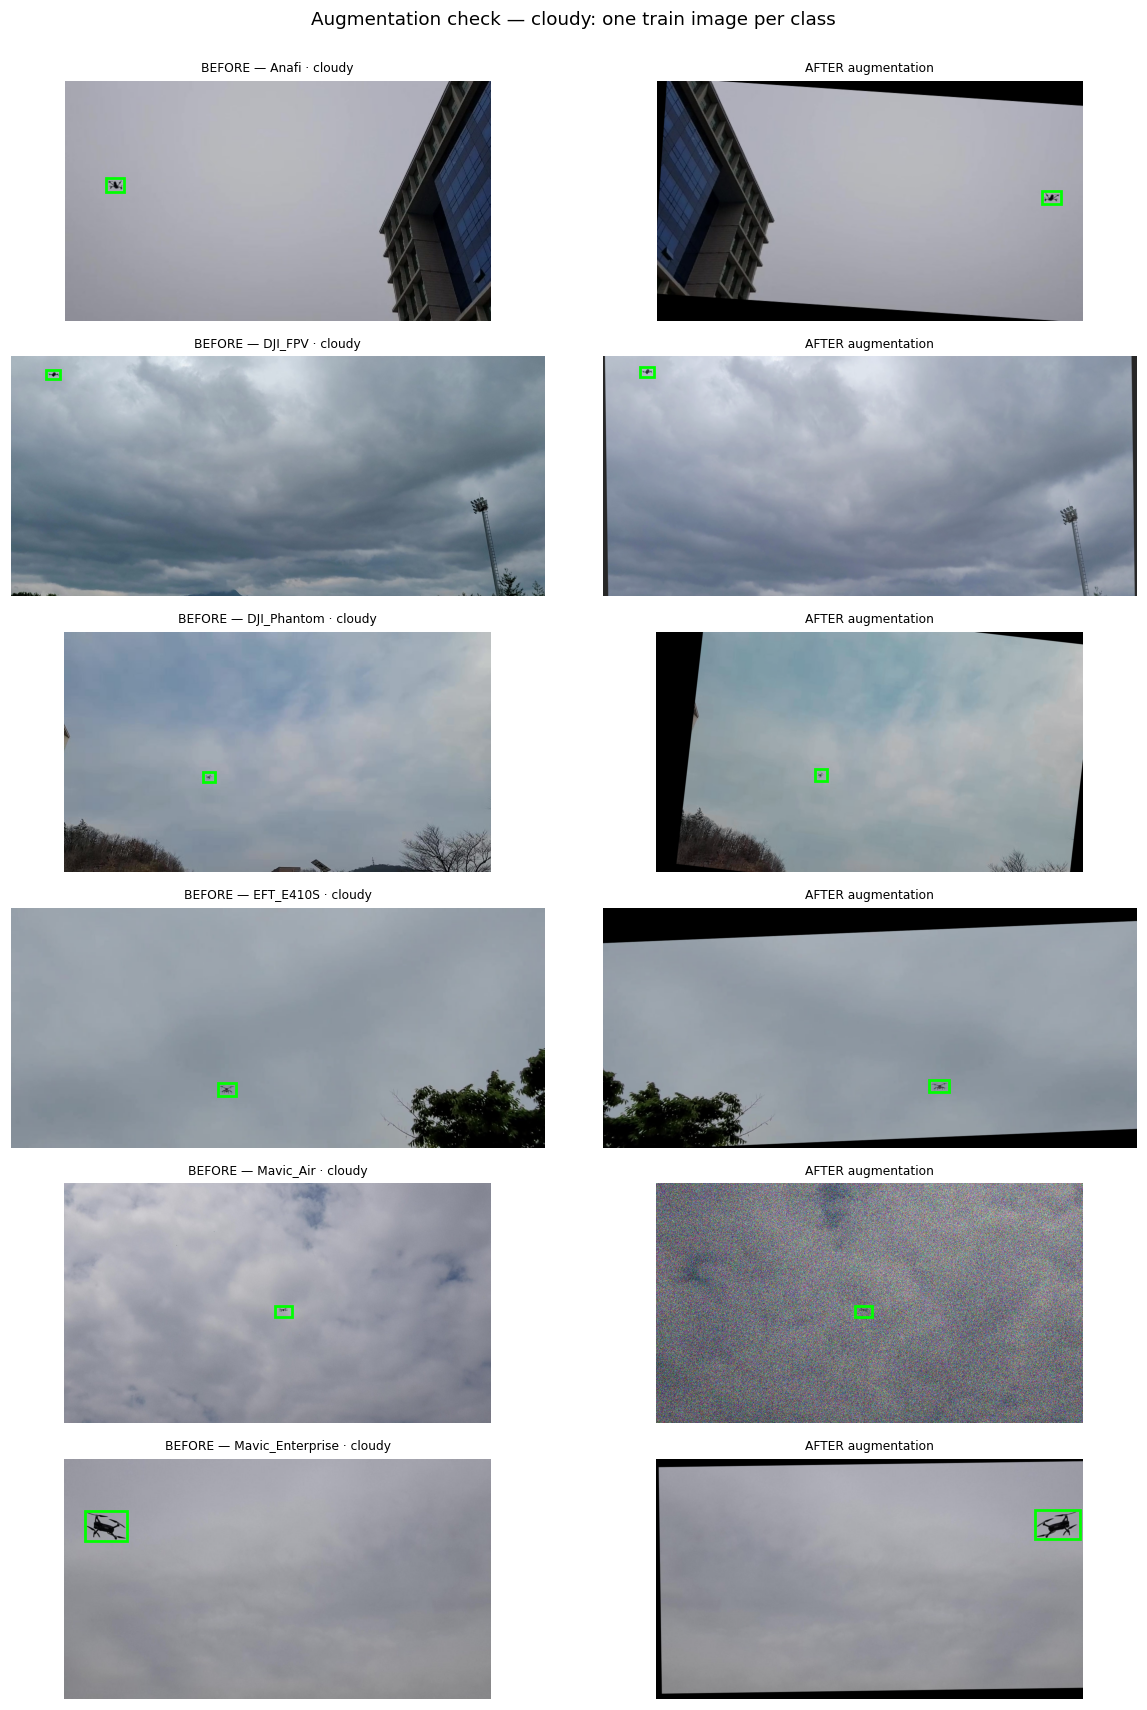

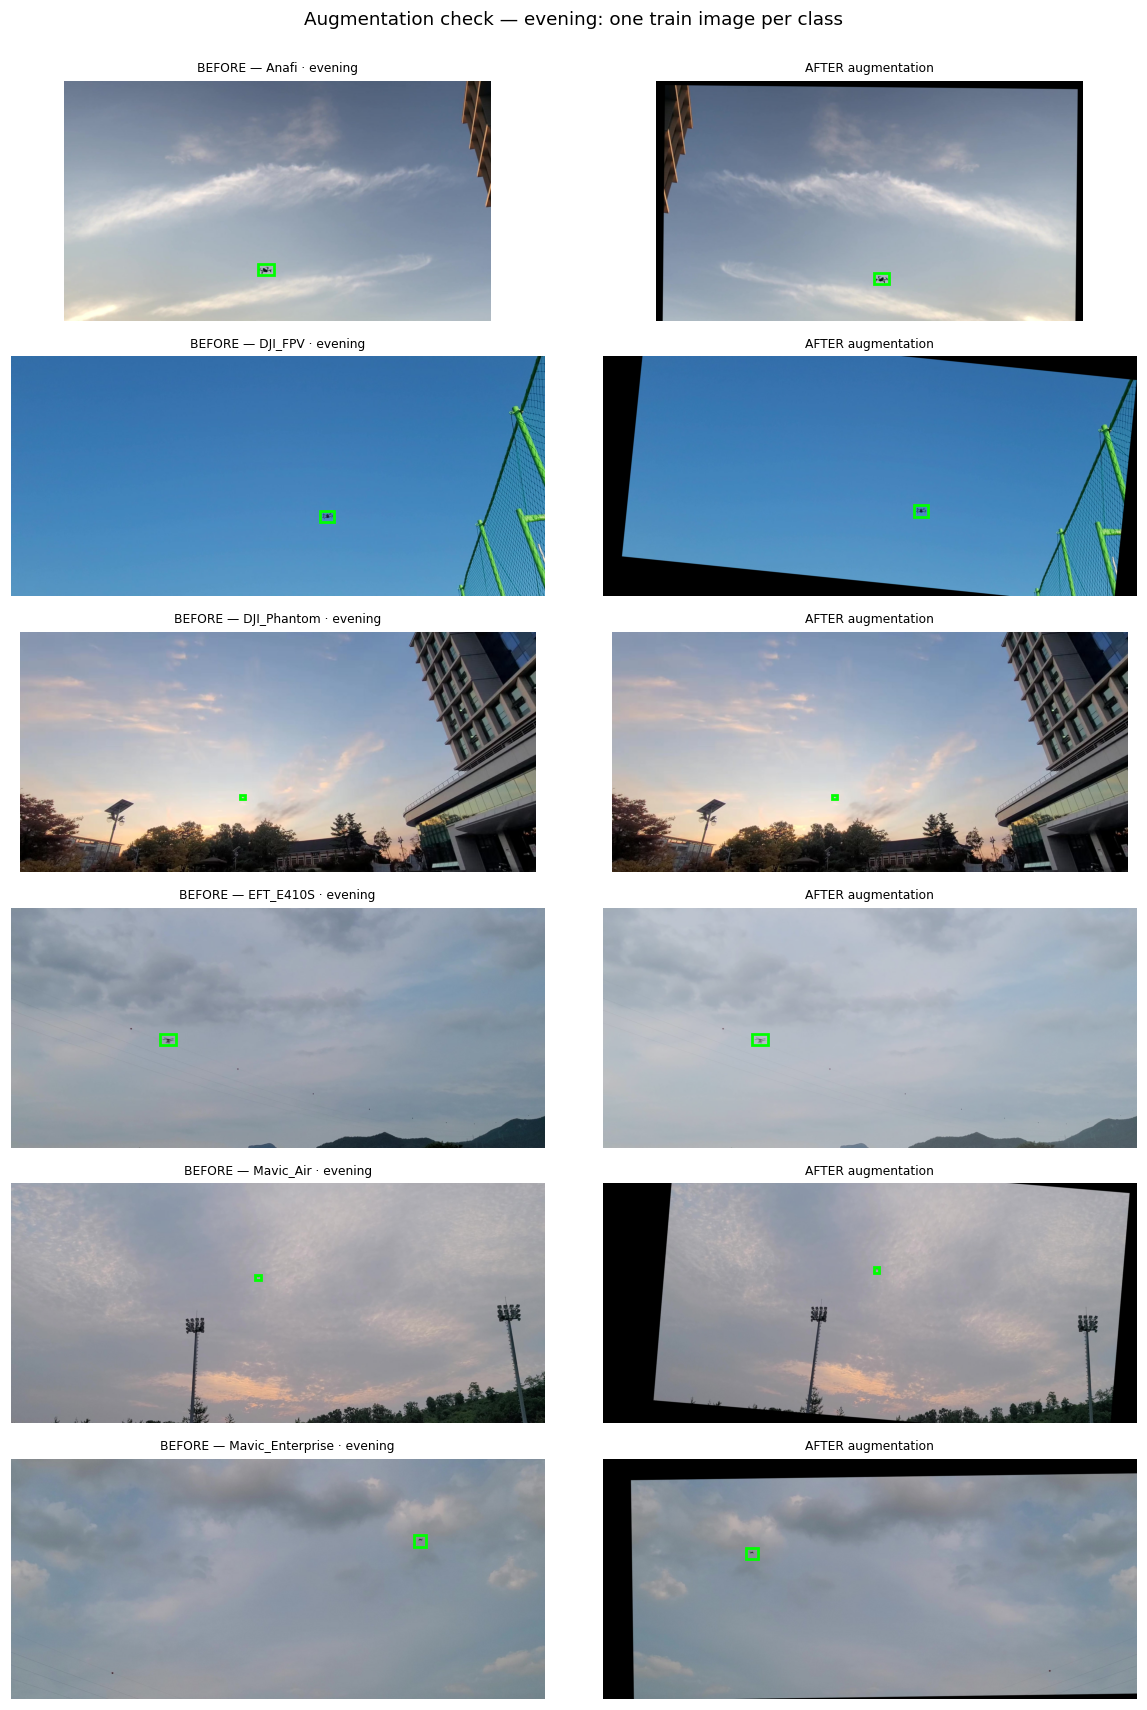

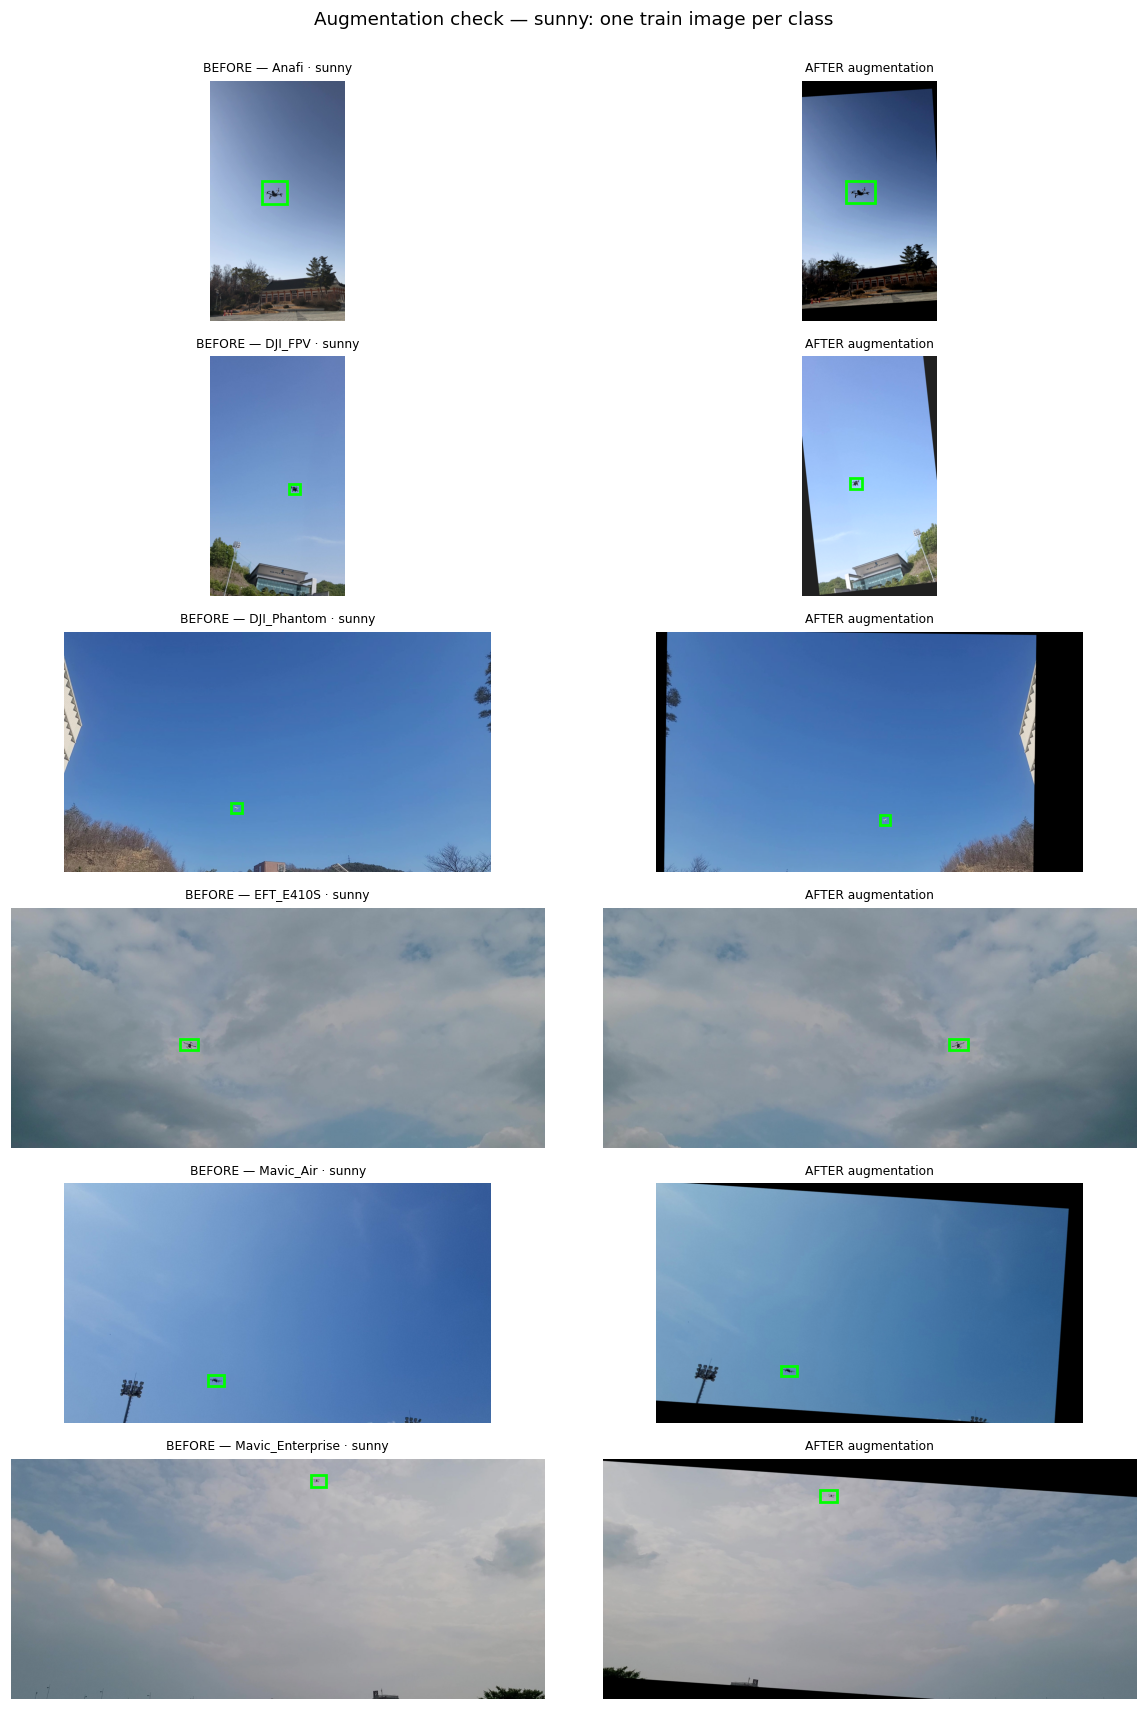

Alignment issues found: 0
✔ Boxes remain valid, normalised and aligned after every transform across all 18 class×scenario samples (class indices carried through label_fields).


In [18]:
def load_yolo_sample(img_path, lbl_path):
    im = np.array(Image.open(img_path).convert("RGB"))
    bbs, cids = [], []
    for ln in Path(lbl_path).read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            cids.append(int(t[0])); bbs.append(tuple(map(float, t[1:])))
    return im, bbs, cids

def show_boxes(ax, im, bbs, title):
    H, W = im.shape[:2]
    ax.imshow(im); ax.set_axis_off(); ax.set_title(title, fontsize=8)
    for cx, cy, w, h in bbs:
        ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                        fill=False, edgecolor="lime", lw=1.8))

# one train-split image per class for EACH scenario -> 3 figures of 6 before/after pairs
train_split = df[df.split == "train"]
alignment_issues = 0
for scen in SCENARIOS:
    fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(11, 15.5))
    for ci, cname in enumerate(CLASS_NAMES):
        ax_b, ax_a = axes[ci]; ax_b.set_axis_off(); ax_a.set_axis_off()
        sub = train_split[(train_split.class_name == cname) &
                          (train_split.scenario == scen)]
        if sub.empty:
            ax_b.set_title(f"{cname} · {scen}: no train images", fontsize=8); continue
        r = sub.sample(1, random_state=SEED).iloc[0]
        stem = f"{r.class_name}_{r.scenario}_{Path(r.image).stem}"
        ip = Path(OUTPUT_DIR) / "train" / "images" / (stem + Path(r.image).suffix.lower())
        lp = Path(OUTPUT_DIR) / "train" / "labels" / (stem + ".txt")
        im, bbs, cids = load_yolo_sample(ip, lp)
        out = train_tfms(image=im, bboxes=bbs, class_ids=cids)
        show_boxes(ax_b, im, bbs, f"BEFORE — {cname} · {scen}")
        show_boxes(ax_a, out["image"], out["bboxes"], "AFTER augmentation")
        for cx, cy, w, h in out["bboxes"]:
            if not (0 <= cx-w/2+1e-6 and cx+w/2 <= 1+1e-6 and
                    0 <= cy-h/2+1e-6 and cy+h/2 <= 1+1e-6 and w > 0 and h > 0):
                alignment_issues += 1
    fig.suptitle(f"Augmentation check — {scen}: one train image per class", y=1.0)
    plt.tight_layout(); save_show(f"7_1_before_after_{scen}")

print("Alignment issues found:", alignment_issues)
assert alignment_issues == 0, "Fix coordinate handling before training!"
print("✔ Boxes remain valid, normalised and aligned after every transform across all "
      "18 class×scenario samples (class indices carried through label_fields).")


## 8. Written Summary — Dataset Characteristics → Modelling Decisions

VisioDECT provides ≈20.9 k ground-to-air drone images across **6 rotary-wing classes** and
**3 lighting scenarios**, with **exactly one drone per labeled image**. The class balance
depends directly on the Section 3.5 recovery: 1,507 images (including the entire
Anafi-cloudy scenario) ship without TXT or VOC-XML labels and are recoverable only from the
IoU-verified CSV annotations — the final imbalance ratio and per-cell counts are printed in
§4.1 from whatever the recovery achieved, and stratified splitting (verified leakage-free via
MD5 hashing) handles the residual skew. The committed run measures a median box area of
≈3.6 k px² (≈60 px side): **83.6 % of boxes fall in the medium COCO bin** and only ≈6.6 %
below the 32² small threshold, so the baseline **640 px input resolution is adequate** and
1280 is held in reserve only if small-object recall stalls; per-class medians in §4.5b show
DJI-FPV presents the smallest (hardest) targets. Lighting is the dominant variation —
§4.5a measures a ≈16-grey-level brightness gap from cloudy (brightest) to sunny — so
photometric augmentation matters more than heavy geometry, and error analysis in
Notebooks 2–5 must be sliced per scenario and per class. With ≈13.6–14.6 k training images
the Section-4.1 sizing table places us in the **8 k–20 k band**: we will train **YOLO `m`**
(stepping to `l` only if `m` plateaus within the T4 budget) and **RF-DETR `base`**,
re-justified in each notebook's CONFIG cell against these numbers.

---
*End of Notebook 1 — commit with all outputs visible, set visibility to **Public**, then use
this notebook's output (`visiodect_yolo/`, `data.yaml`, `eda_outputs/`) as the input dataset
for Notebooks 2–5.*

## 9. Export & Handoff for Notebooks 2–5
Every Notebook producrd output is written to `/kaggle/working/` so it survives
the Kaggle **Save Version** commit and stays viewable without re-running:

| Artifact | Path | Purpose |
|---|---|---|
| Leakage-free YOLO dataset | `visiodect_yolo/{train,val,test}/{images,labels}` + `data.yaml` | Training input for NB 2–5 |
| Recovered labels | `recovered_labels/` | YOLO TXT files recovered from VOC-XML and IoU-verified CSV (Sections 3.5–3.6) |
| Split manifest (audit trail) | `split_manifest.csv` — original path, new name, split, class, scenario, **MD5** | Viva evidence for the leakage check |
| EDA summary | `eda_summary.json` | Machine-readable stats cited by NB 2–5 CONFIG cells |
| **All figures & tables** | `eda_outputs/*.png`, `eda_outputs/*.csv` | Every plot and report table from Sections 3–7, saved for later viewing |

The dataset is **not zipped**: Kaggle preserves `/kaggle/working/` as the notebook output on
commit, and zipping 2+ GB would double the output size for no benefit.

In [19]:
# ---- 9.1 split manifest (audit trail for the leakage check) ----------------
manifest = df[["image", "md5", "class_id", "class_name", "scenario", "split",
               "width", "height", "n_boxes"]].copy()
manifest["exported_name"] = manifest.apply(
    lambda r: f"{r.class_name}_{r.scenario}_{Path(r.image).stem}"
              + Path(r.image).suffix.lower(), axis=1)
manifest.to_csv("/kaggle/working/split_manifest.csv", index=False)

# ---- 9.2 EDA summary consumed by the CONFIG cells of Notebooks 2-5 ---------
eda_summary = {
    "dataset": DATASET_SLUG,
    "annotation_format": ANNOTATION_FORMAT,
    "class_names": CLASS_NAMES,
    "images_total": int(len(df)),
    "duplicates_dropped_md5": int(dups.sum()),
    "class_counts": df.class_name.value_counts().sort_index().to_dict(),
    "imbalance_ratio_max_min": round(float(imb), 3),
    "small_object_share": round(float(sm), 4),
    "median_box_area_px2": float(boxes.area.median()),
    "split_ratios": SPLIT_RATIOS,
    "seed": SEED,
    "per_split_counts": df.split.value_counts().to_dict(),
    "img_size_baseline": IMG_SIZE,
    "labels_recovered_relaxed_txt": int(recovered_txt),
    "labels_recovered_voc_xml": int(recovered_xml),
    "labels_recovered_verified_csv": int(recovered_csv),
    "images_excluded_unlabeled": int(excluded_unlabeled),
    "size_bin_shares": {str(k): round(float(v), 4) for k, v in shares.items()},
    "brightness_mean_by_scenario": bri_stats["mean"].to_dict(),
}
Path("/kaggle/working/eda_summary.json").write_text(json.dumps(eda_summary, indent=2))
print(json.dumps(eda_summary, indent=2))

# ---- 9.3 final handoff verification -----------------------------------------
print("\n--- /kaggle/working contents ---")
for pth in sorted(Path("/kaggle/working").iterdir()):
    print(" ", pth.name)
print("\n--- saved figures & tables (eda_outputs/) ---")
for pth in sorted(EDA_OUT.iterdir()):
    print(" ", pth.name)
n_tr = len(list((Path(OUTPUT_DIR)/"train"/"images").iterdir()))
n_va = len(list((Path(OUTPUT_DIR)/"val"/"images").iterdir()))
n_te = len(list((Path(OUTPUT_DIR)/"test"/"images").iterdir()))
assert n_tr + n_va + n_te == len(df), "Export count mismatch!"
assert len(manifest) == len(df) and manifest.md5.nunique() == len(df)
print(f"\n✔ Export verified: {n_tr:,}+{n_va:,}+{n_te:,} = {len(df):,} images, "
      "manifest complete, all MD5s unique.")
print("\nNEXT: Save Version (commit) -> in NB 2-5 use 'Add Input' -> 'Your Work' "
      "-> this notebook's output.")


{
  "dataset": "simeonajakwe/visiodect-for-scenario-based-multi-drone-detection",
  "annotation_format": "YOLO TXT",
  "class_names": [
    "Anafi",
    "DJI_FPV",
    "DJI_Phantom",
    "EFT_E410S",
    "Mavic_Air",
    "Mavic_Enterprise"
  ],
  "images_total": 20603,
  "duplicates_dropped_md5": 14,
  "class_counts": {
    "Anafi": 3375,
    "DJI_FPV": 3439,
    "DJI_Phantom": 3300,
    "EFT_E410S": 3552,
    "Mavic_Air": 3519,
    "Mavic_Enterprise": 3418
  },
  "imbalance_ratio_max_min": 1.076,
  "small_object_share": 0.0903,
  "median_box_area_px2": 3453.3871309440005,
  "split_ratios": [
    0.7,
    0.15,
    0.15
  ],
  "seed": 42,
  "per_split_counts": {
    "train": 14422,
    "test": 3091,
    "val": 3090
  },
  "img_size_baseline": 640,
  "labels_recovered_relaxed_txt": 0,
  "labels_recovered_voc_xml": 0,
  "labels_recovered_verified_csv": 1200,
  "images_excluded_unlabeled": 307,
  "size_bin_shares": {
    "small (<32\u00b2)": 0.0903,
    "medium (32\u00b2\u201396\u00b2)": 

### Handoff checklist 
- [ ] All cells executed top-to-bottom with outputs visible (assignment §7.1)
- [ ] Leakage assertion in Section 5 printed **PASSED**
- [ ] `split_manifest.csv` and `eda_summary.json` present in `/kaggle/working/`
- [ ] Notebook visibility set to **Public**; link tested in incognito
- [ ] Group number / member names filled into the title and CONFIG cells